# Matplotlib — Chart Fundamentals

> 📘 **Instructor Curriculum** — M02, Data Visualization with Python

**What this notebook is:** a hands-on tour of `matplotlib.pyplot`, covering six chart families (line, scatter, bar, histogram, pie, fill) plus the styling arguments that apply across all of them.

**How to read it:** this notebook is a **ladder**. Almost every cell repeats the cell above it and changes exactly one thing. So the useful question at each step is *what is different from the cell before?* Each Markdown section below explains every code cell that follows it, up to the next section.

Matplotlib version used here: **3.10.9**.

---

## The mental model — read this first

Every cell below is `plt.something(...)`, and that hides an object tree:

```text
Figure  ......... the whole canvas / the page
  |
  +-- Axes  ..... ONE plot area  (not "axis" - an Axes HOLDS two Axis objects)
        |
        +-- Artists ... the things actually drawn: lines, dots, bars, wedges
        +-- Axis ...... ticks, limits, tick labels
```

Which call touches what:

| Call | Acts on |
|---|---|
| `plt.plot`, `plt.scatter`, `plt.bar`, `plt.pie` | the **current Axes** — draws into it |
| `plt.title`, `plt.xlabel`, `plt.ylabel`, `plt.grid` | the **current Axes** — decorates it |
| `plt.suptitle`, `plt.savefig`, `plt.show` | the **current Figure** |

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor curriculum.*
>
> `pyplot` keeps a hidden "current figure / current Axes" pointer, exactly like Spring's `RequestContextHolder` keeps the request in a thread-local so you can reach it without passing it around. `plt.title(...)` never says *which* chart it titles — it targets whatever is current. That is why cell order matters in this notebook, and why the explicit style (`fig, ax = plt.subplots()` then `ax.set_title(...)`) is what production code should use: constructor injection instead of a global lookup.

The flow in every single cell of this notebook is the same:

```text
data (np.array or list)
   -> a plotting call     plt.plot / scatter / bar / hist / pie
   -> styling calls       plt.title / xlabel / ylabel / grid
   -> plt.savefig(...)    (before show, if saving)
   -> plt.show()          renders AND clears the figure
```


## 1. Setup — the import cells

| Cell | Why it exists |
|---|---|
| `import matplotlib` | Imports the **top-level package only**. Gives version info and config (`matplotlib.rcParams`) but **not** the plotting functions — which is why a second import follows. |
| `print(matplotlib.__version__)` | Prints `3.10.9`. Checking the version first is a good habit: matplotlib keyword arguments have changed across major versions, so a snippet from the internet that fails may simply be written for a different one. |
| `import matplotlib.pyplot as plt` | `pyplot` is the **submodule** that holds `plot`, `scatter`, `bar`, `show`, … The alias `plt` is universal convention. |
| `import numpy as np` | Most data below is built with `np.array`. Matplotlib accepts plain Python lists too — the annotation cells near the end prove it. |

**Takeaway:** `matplotlib` is the library, `matplotlib.pyplot` is the drawing API. Importing the first does not give you the second.


In [78]:
import matplotlib

In [3]:
print(matplotlib.__version__)

3.10.9


In [5]:
import matplotlib.pyplot as plt
import numpy as np

---

## 2. Line plots and the format-string shortcut

The next 12 cells all reuse the same two arrays:

```python
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
```

`y` is exactly `2 * x`, so the true shape is a straight line through the origin with slope 2. That is deliberate: when the data is boring and predictable, **any change you see on screen is caused by the style argument, not by the data.** Clean experiment design.

### The baseline — `plt.plot(x, y)`

| Line | What it does |
|---|---|
| `plt.plot(x, y)` | Pairs the arrays element-wise into points `(1,2), (2,4) … (10,20)` and connects them with a solid line. Both arrays **must be the same length**, or you get `ValueError: x and y must have same first dimension`. |
| `plt.show()` | Renders the figure, then **clears** it so the next cell starts on a fresh canvas. |

Defaults you get silently: line style `-` solid, line width `1.5`, no markers, and the first color of the property cycle (`#1f77b4`, a medium blue).

*On `plt.show()` in Jupyter:* the chart would display without it, but the call also suppresses the `[<matplotlib.lines.Line2D ...>]` repr text that would otherwise print above the image. Keeping it is correct, and it makes the code portable to a `.py` script where it is mandatory.

### The format string

The third positional argument is a compact shorthand for `[marker][linestyle][color]`.

| Code | Result | Rule it teaches |
|---|---|---|
| `'o'` | circle markers, **no line** | marker only ⇒ the connecting line disappears |
| `'s'` | square markers, no line | same rule |
| `'d'` | thin diamond, no line | `'D'` uppercase is the fat diamond |
| `'p'` | pentagon, no line | same rule |
| `'r'` | red **solid line** | color only ⇒ the default line is kept |
| `'g'` | green solid line | same rule |

Those two blocks are the lesson, learned by contrast: **adding a marker removes the line; adding a color does not.**

Single-letter colors: `b` blue, `g` green, `r` red, `c` cyan, `m` magenta, `y` yellow, `k` black, `w` white.

### The same thing as a keyword

`plt.plot(x, y, marker="*")` is identical in effect to passing `'*'`. Format strings are terse; keywords are readable and self-documenting. Both appear here so you can read other people's code.

### All three parts at once

| Code | Marker | Line style | Color |
|---|---|---|---|
| `'o-r'` | circle | `-` solid | red |
| `'o:g'` | circle | `:` dotted | green |
| `'o--y'` | circle | `--` dashed | yellow |
| `'o-.m'` | circle | `-.` dash-dot | magenta |

Matplotlib parses the three parts in **any order** — `'o-r'`, `'-or'` and `'ro-'` are the same chart. The one real trap: `'-.'` (dash-dot) and `'-'` followed by a `.` marker look alike in text. Read them carefully.


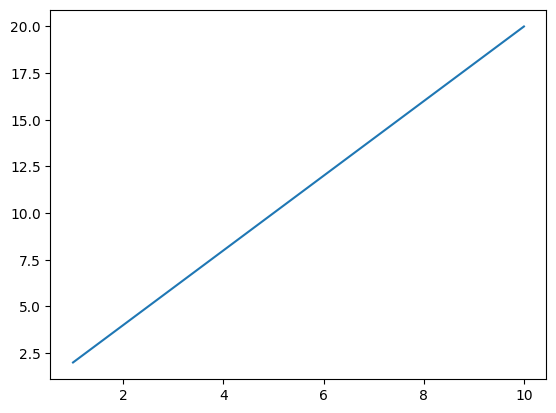

In [7]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y)
plt.show()

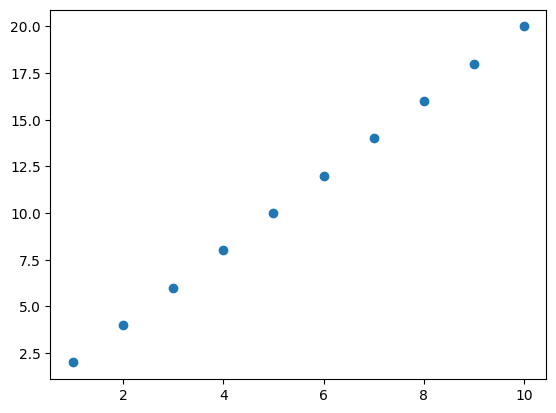

In [8]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'o')
plt.show()

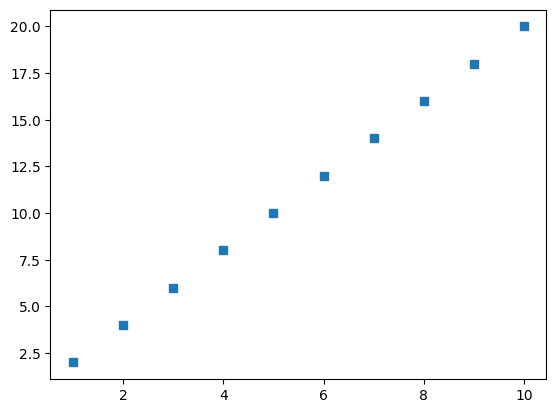

In [9]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'s')
plt.show()

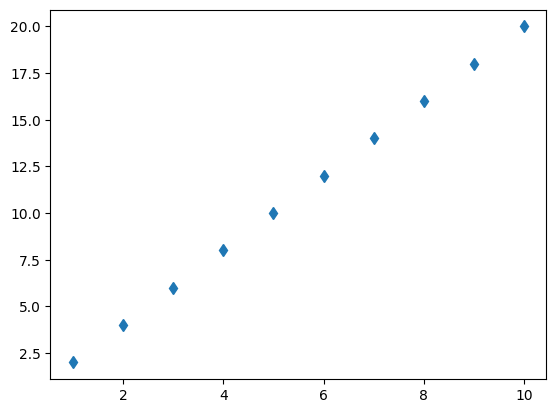

In [10]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'d')
plt.show()

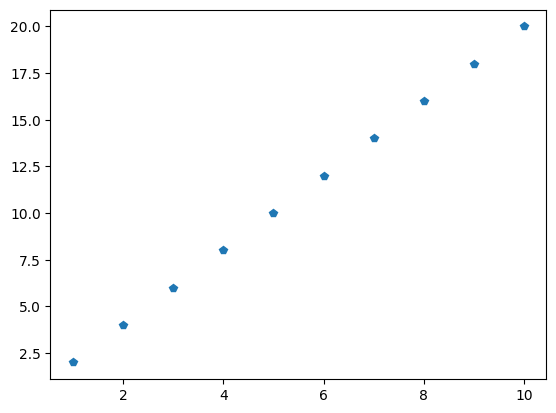

In [11]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'p')
plt.show()

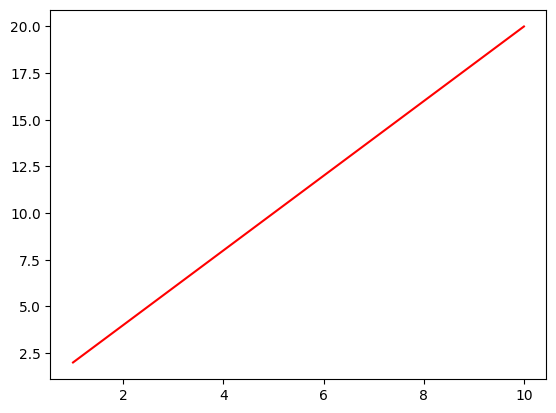

In [12]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'r')
plt.show()

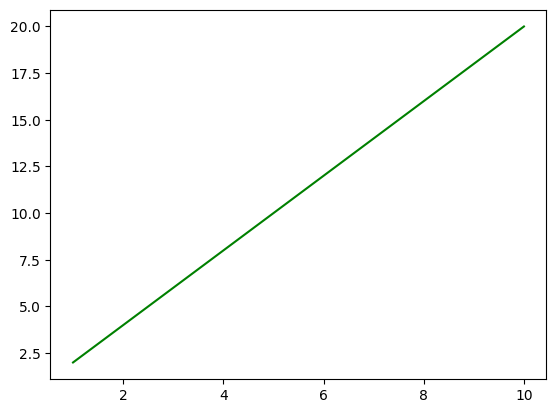

In [13]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'g')
plt.show()

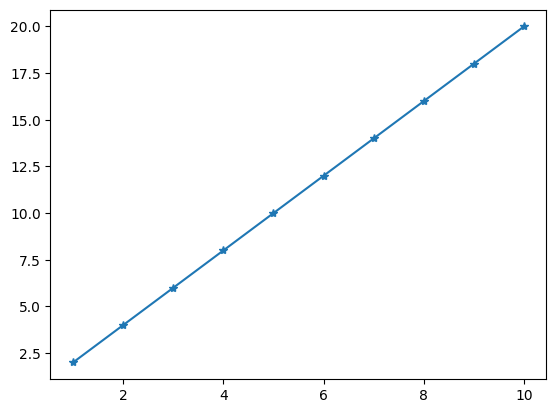

In [14]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,marker ="*")
plt.show()

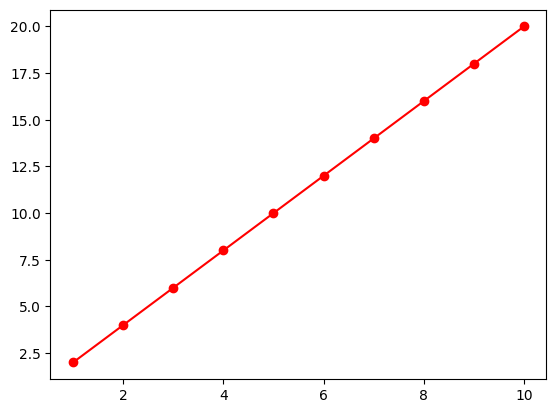

In [15]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'o-r')
plt.show()

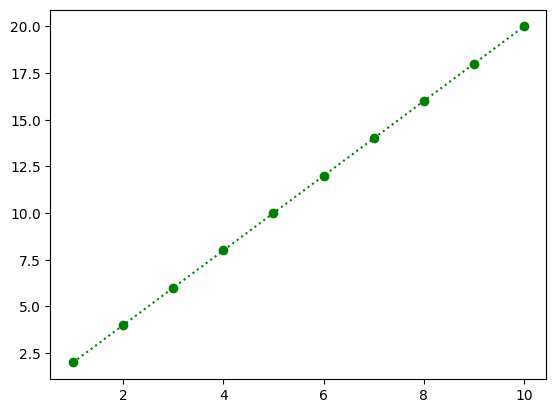

In [17]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'o:g')
plt.show()

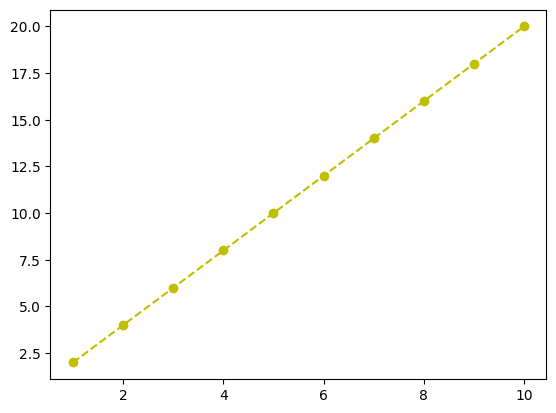

In [18]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'o--y')
plt.show()

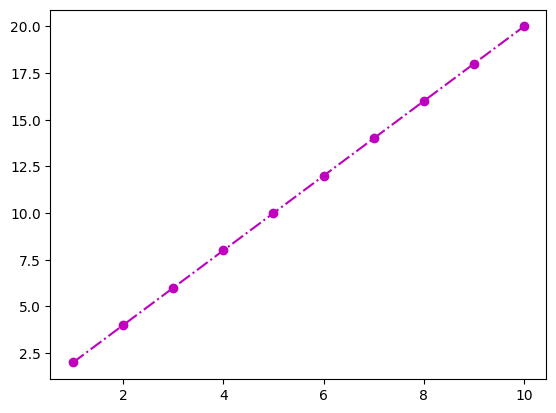

In [20]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,'o-.m')
plt.show()

---

## 3. Styling markers and lines with keywords

### The marker aliases

Five separate visual channels are controlled in the next two cells. The short names are aliases matplotlib accepts for the long ones:

| Alias | Full name | Controls | 1st cell | 2nd cell |
|---|---|---|---|---|
| `c` | `color` | the **connecting line** | yellow | magenta |
| `marker` | — | symbol shape | circle | circle |
| `ms` | `markersize` | symbol size, **in points (diameter)** | 10 | 20 |
| `mec` | `markeredgecolor` | symbol border | black | black |
| `mfc` | `markerfacecolor` | symbol fill | magenta | yellow |

The second cell is the first one with the line and fill colors swapped and the marker doubled in size. It exists to prove `c` and `mfc` are genuinely independent — a common beginner confusion is expecting one `color` argument to control everything.

⚠️ `ms` here is a **diameter in points**. In `plt.scatter` further down, the size argument `s` is an **area in points²**. Different scales — `ms=20` and `s=20` produce very different dots.

### Line style by name and by symbol

`linestyle='dotted'` and `linestyle=':'` draw the **identical chart**. That is the whole point of running them next to each other:

| Name | Symbol |
|---|---|
| `'solid'` | `'-'` |
| `'dashed'` | `'--'` |
| `'dotted'` | `':'` |
| `'dashdot'` | `'-.'` |

These cells pass no marker, so the markers are gone again and only the styled line remains.


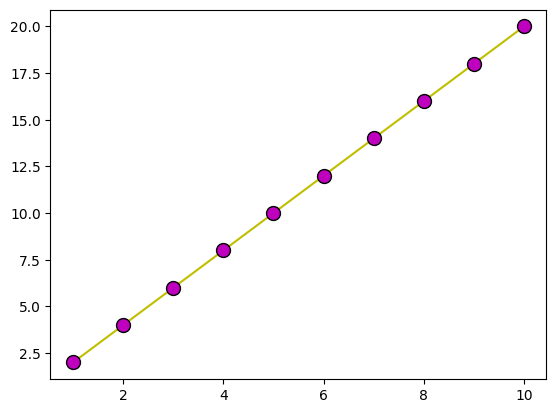

In [21]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,c='y',marker='o',ms=10,mec='k',mfc='m')
plt.show()

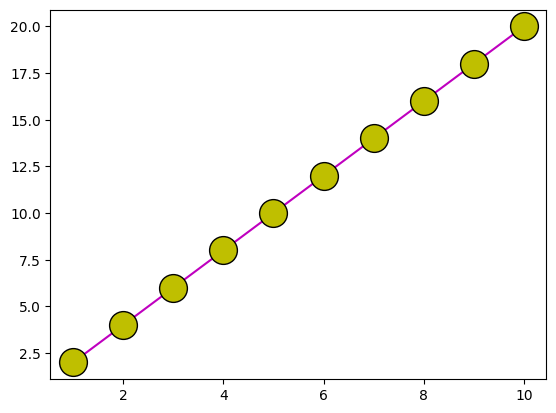

In [22]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,c='m', marker = 'o', ms = 20, mec = 'k', mfc = 'y')
plt.show()

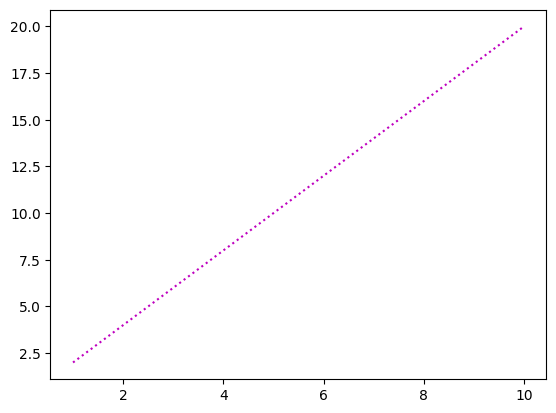

In [23]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,linestyle = 'dotted',c='m')
plt.show()

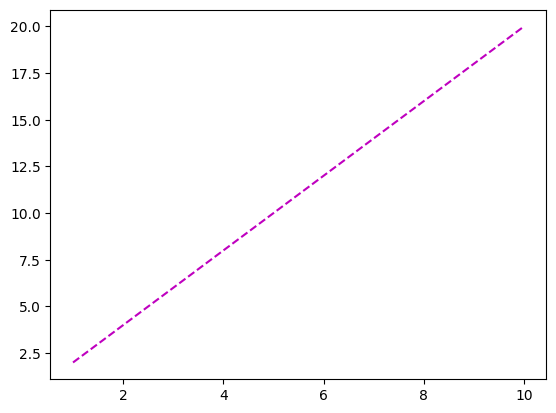

In [24]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,linestyle = 'dashed',c='m')
plt.show()

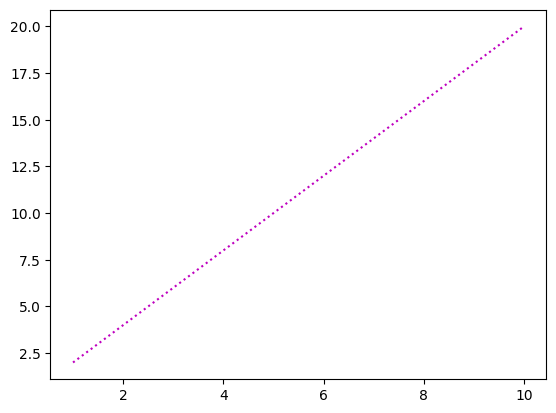

In [25]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.plot(x,y,linestyle = ':',c='m')
plt.show()

---

## 4. Titles, axis labels, and grid

The first charts here that actually communicate something.

| Line | Explanation |
|---|---|
| `plt.title("Plot", loc="left")` | Title above the Axes. `loc` accepts `'left'`, `'center'` (the default), `'right'`. |
| `plt.xlabel("X Axis")` | Label under the horizontal axis. |
| `plt.ylabel("Y axis")` | Label beside the vertical axis, rotated 90°. |
| `c='#00ffbd'` | A **hex RGB color** (bright turquoise) — you are not restricted to the 8 single-letter colors. |
| `plt.grid(color='r', linestyle=':', linewidth=0.6)` | Turns the grid on and styles it: red, dotted, thin. A grid helps a reader estimate values off the chart. |

**Notice the ordering.** The title and label calls come *before* `plt.plot`, yet they still apply — because they all target the same current Axes, which pyplot creates on the first call that needs one. It reads oddly, though; **draw first, then decorate** is the convention that matches how people read code.

⚠️ `linewidth='10'` passes a **string**. Matplotlib converts it to `10.0`, so the chart is correct, but it works by accident. Write `linewidth=10`.

Two more grid facts worth knowing: `plt.grid(axis='y')` draws horizontal lines only, and calling `plt.grid()` a second time **toggles it off** — so pass `True` / `False` explicitly when it matters.


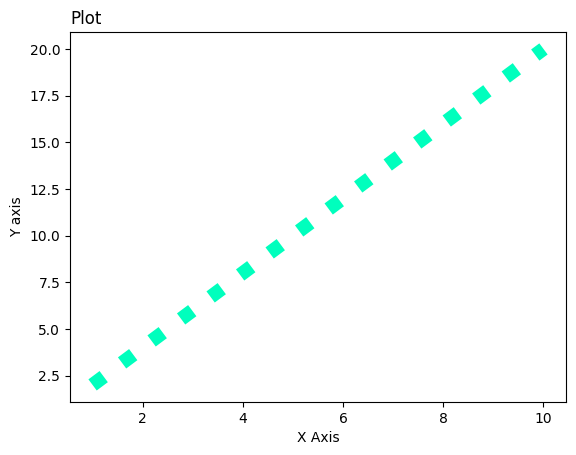

In [26]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.title("Plot",loc="left")
plt.xlabel("X Axis")
plt.ylabel("Y axis")
plt.plot(x,y,linestyle = 'dotted', linewidth='10',c='#00ffbd')
plt.show()

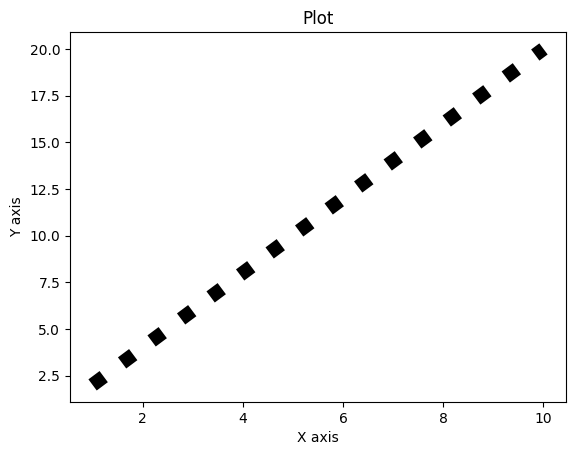

In [27]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.title("Plot", loc = 'center')
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.plot(x,y,linestyle = 'dotted',linewidth = '10',c='k')
plt.show()

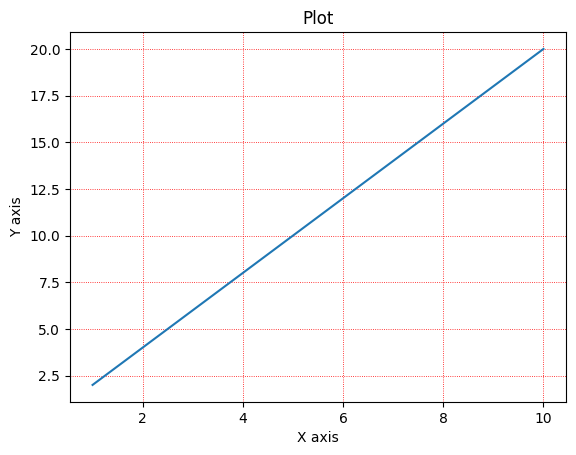

In [36]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
plt.title("Plot", loc = 'center')
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.plot(x,y)
plt.grid(color = 'r', linestyle = ':', linewidth = 0.6)
plt.show()

---

## 5. Subplots — several charts on one figure

`plt.subplot(nrows, ncols, index)`

- `nrows`, `ncols` describe the **grid** you divide the figure into
- `index` selects **which panel** you are about to draw in
- indexing starts at **1**, not 0, running left-to-right then top-to-bottom

Every call after `plt.subplot(...)` targets that panel until the next `plt.subplot(...)` switches the current Axes.

| Cell uses | Grid | Layout |
|---|---|---|
| `(1, 2, 1)` and `(1, 2, 2)` | 1 row × 2 cols | side by side |
| `(2, 1, 1)` and `(2, 1, 2)` | 2 rows × 1 col | stacked — only the grid changed |
| `(2, 2, 1)` and `(2, 2, 2)` | 2 rows × 2 cols | four panels, only the top two drawn, so the bottom row is empty whitespace |

Side-by-side is better for comparing shapes; stacked with a shared x-axis is better for comparing values at the same x. The half-empty 2×2 is useful to *see* once so the numbering clicks — but in real work, size the grid to the number of charts you actually have.

### Panel title vs figure title

The last cell of this group is the important one:

| Call | Scope | Result |
|---|---|---|
| `plt.title(...)` | current **Axes** | one heading per panel |
| `plt.suptitle(...)` | the **Figure** | one heading above everything |

Because `plt.title` follows the current-Axes rule, **position matters**: `"First"` lands on panel 1 only because it is called before the second `plt.subplot` switches context. Move that line down and the title moves with it. This is the mental model from the top of the notebook, in code.


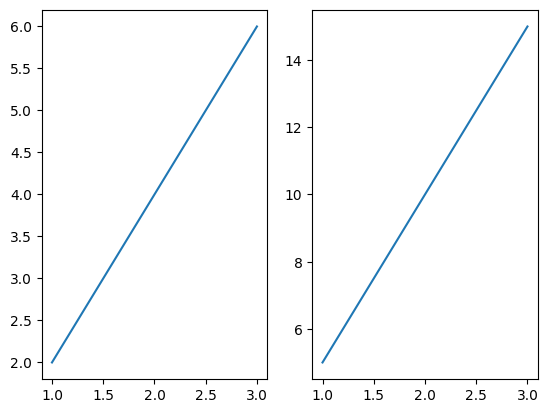

In [38]:
a = np.array([1, 2, 3])
b = np.array([2, 4, 6])
plt.subplot(1, 2, 1)
plt.plot(a,b)
c = np.array([1, 2, 3])
d = np.array([5, 10, 15])
plt.subplot(1, 2, 2)
plt.plot(c,d)
plt.show()

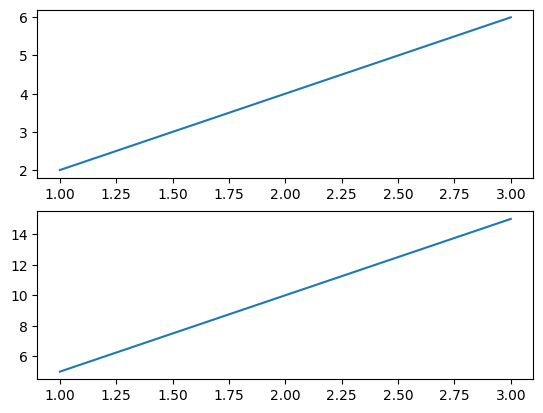

In [39]:
a = np.array([1, 2, 3])
b = np.array([2, 4, 6])
plt.subplot(2, 1, 1)
plt.plot(a,b)
c = np.array([1, 2, 3])
d = np.array([5, 10, 15])
plt.subplot(2, 1, 2)
plt.plot(c,d)
plt.show()

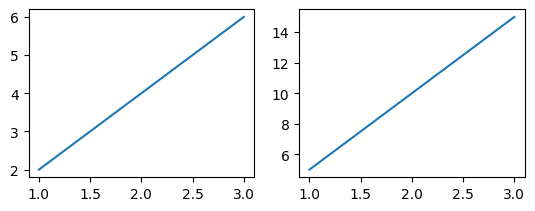

In [40]:
a = np.array([1, 2, 3])
b = np.array([2, 4, 6])
plt.subplot(2, 2, 1)
plt.plot(a,b)
c = np.array([1, 2, 3])
d = np.array([5, 10, 15])
plt.subplot(2, 2, 2)
plt.plot(c,d)
plt.show()

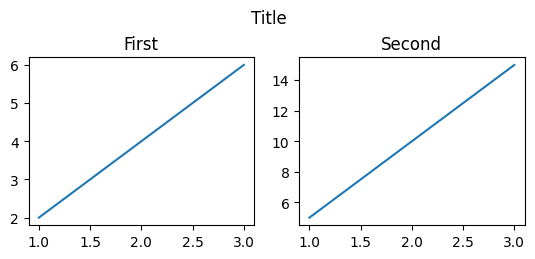

In [41]:
a = np.array([1, 2, 3])
b = np.array([2, 4, 6])
plt.subplot(2, 2, 1)
plt.plot(a,b)
plt.title("First")
c = np.array([1, 2, 3])
d = np.array([5, 10, 15])
plt.subplot(2, 2, 2)
plt.plot(c,d)
plt.title("Second")
plt.suptitle("Title")
plt.show()

---

## 6. Scatter plots

A scatter plot draws points **without connecting them**. Use it when x and y are paired observations and row order means nothing — a line plot implies a sequence, a scatter does not.

The data changes here (`y = [5,7,2,1,3,4,7,6,8,3]` is unordered), so there is no longer a straight line to hide behind.

### Series-level color

| Code | Effect |
|---|---|
| `plt.scatter(x, y)` | 10 dots, default blue |
| two `scatter` calls in one cell | Matplotlib does **not** clear between calls — it layers. The second series automatically takes the next color in the cycle (orange). |
| `color='m'` | a **single value** ⇒ applies to the whole series |
| `color=colors` (array of names) | an **array** ⇒ applies element-wise, dot *i* gets `colors[i]`. Length must match the number of points. |

⚠️ Two traps in this group. The two-series cells have **no legend**, so a reader cannot tell the groups apart — the fix is `label="..."` on each call plus `plt.legend()`. And the per-point color array contains `"white"`, so that dot is drawn on a white background and is **invisible**: only 9 dots appear. The chart did not error, it silently lost data.

### Color as data — colormap + colorbar

This is a genuinely different idea, and it is why `c` and `color` are separate arguments:

| Line | Explanation |
|---|---|
| `colorss = np.array([5, 15, 23, …])` | A **third variable** measured at each point — not a color name, a number. |
| `c=colorss` | Feed numbers to `c` and matplotlib maps them onto a color scale: low values one end, high values the other. |
| `cmap='winter'` | Which scale to use. `'winter'` runs blue → green. |
| `plt.colorbar()` | Draws the strip that says which color means which number. **Without it the colors are meaningless**, so this call is not decoration. |

You now have a 3-dimensional chart: x, y, and color.

### Size as data, and everything at once

| Argument | Encodes |
|---|---|
| `x`, `y` | position |
| `c=` + `cmap=` | a third variable, as color |
| `s=` | a fourth variable, as **bubble area in points²** |
| `alpha=0.4` | 40% opacity, so overlapping bubbles stay readable |

In the final cell of this group `sizee` is redefined with much larger values (`2000`, `4000`, `3000`), so the big bubbles overlap — which is exactly the situation `alpha` exists for.

> 💡 `'jet'` is a well-known bad default: it is not perceptually uniform (it creates false bands at the yellow/cyan transitions) and it fails for color-blind readers. `'viridis'` is the modern replacement, and matplotlib's default for a reason. Worth swapping in when you revisit this.


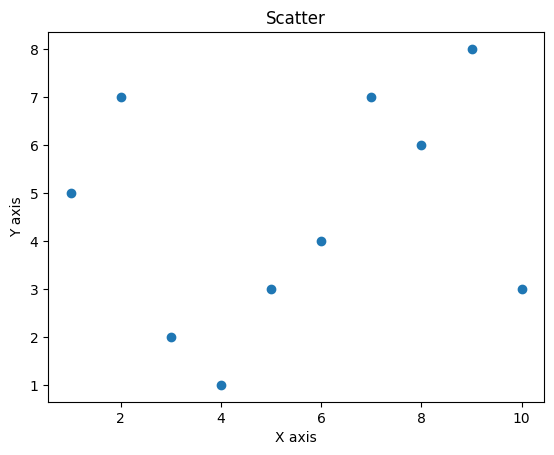

In [42]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([5,7,2,1,3,4,7,6,8,3])
plt.title("Scatter", loc = 'center')
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.scatter(x,y)
plt.show()

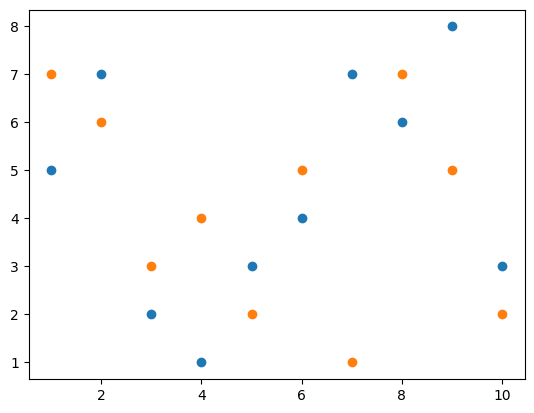

In [43]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([5,7,2,1,3,4,7,6,8,3])
a = np.array([1,2,3,4,5,6,7,8,9,10])
b = np.array([7,6,3,4,2,5,1,7,5,2])
plt.scatter(x,y)
plt.scatter(a,b)
plt.show()

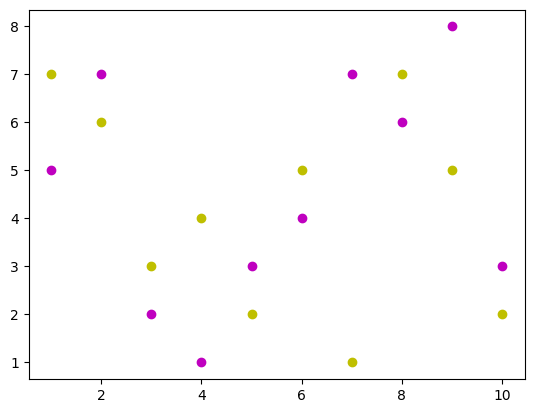

In [44]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([5,7,2,1,3,4,7,6,8,3])
a = np.array([1,2,3,4,5,6,7,8,9,10])
b = np.array([7,6,3,4,2,5,1,7,5,2])
plt.scatter(x,y,color = 'm')
plt.scatter(a,b,color = 'y')
plt.show()

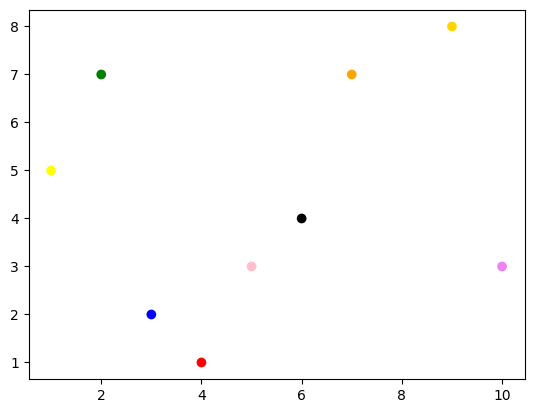

In [48]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([5,7,2,1,3,4,7,6,8,3])
colors = np.array(["yellow","green","blue","red","pink","black","orange","white","gold","violet"])
plt.scatter(x,y,color = colors)
plt.show()

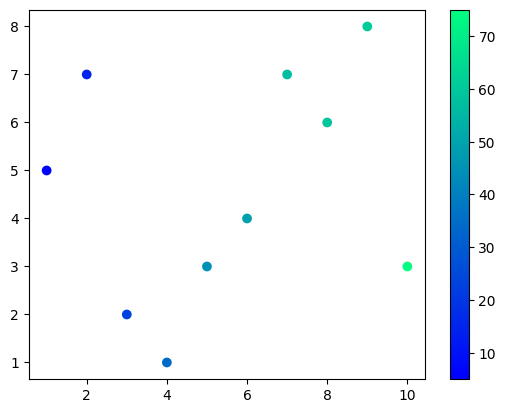

In [49]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([5,7,2,1,3,4,7,6,8,3])
colorss = np.array([5, 15, 23, 34, 45, 49, 57, 59, 61, 75])
plt.scatter(x,y,c=colorss,cmap='winter')
plt.colorbar()
plt.show()

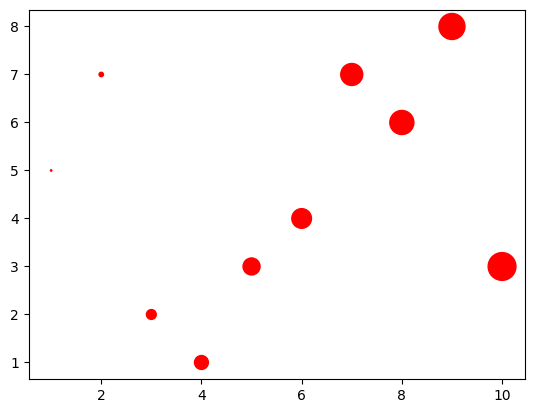

In [50]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([5,7,2,1,3,4,7,6,8,3])
sizee = np.array([1, 10, 50, 100, 150, 200, 250, 300, 350, 400])
plt.scatter(x,y,c='r',s=sizee)
plt.show()

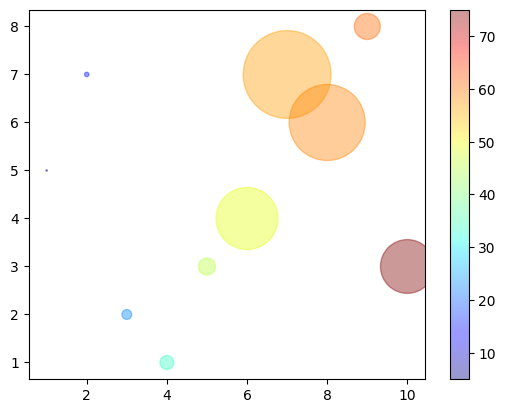

In [51]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([5,7,2,1,3,4,7,6,8,3])
colorss = np.array([5, 15, 23, 34, 45, 49, 57, 59, 61, 75])
sizee = np.array([1, 10, 50, 100, 150, 2000, 4000, 3000, 350, 1500])
plt.scatter(x,y,c=colorss,cmap='jet',s=sizee,alpha=0.4)
plt.colorbar()
plt.show()

---

## 7. Bar charts

Bars compare a **measured value across categories**. The x input becomes strings here, which is the signal that these are categories, not numbers.

| Code | Result |
|---|---|
| `plt.bar(x, y)` | Vertical bars. Categories on the x-axis, value = bar **height**. |
| `plt.barh(x, y)` | **h**orizontal bars. Categories move to the y-axis, value = bar **length**. Prefer this when category names are long. |
| `plt.bar(..., width=0.3)` | `width` is the fraction of its slot each bar fills. Default `0.8`, so `0.3` gives thin bars with wide gaps. |
| `plt.barh(..., height=0.3)` | The same thinning for horizontal bars — but the argument is called **`height`**, because for `barh` the thickness runs vertically. |

That last pair is the one to remember: **`bar` → `width`, `barh` → `height`.** Passing `width` to `barh` sets the bar *length* instead and silently gives you a wrong chart.


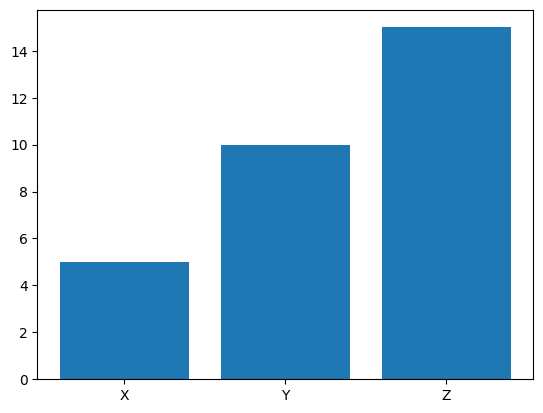

In [52]:
x = np.array(["X", "Y", "Z"])
y = np.array([5, 10, 15])
plt.bar(x,y)
plt.show()

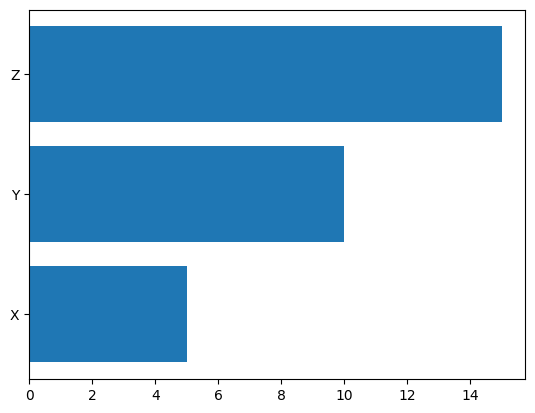

In [53]:
x = np.array(["X", "Y", "Z"])
y = np.array([5, 10, 15])
plt.barh(x,y)
plt.show()

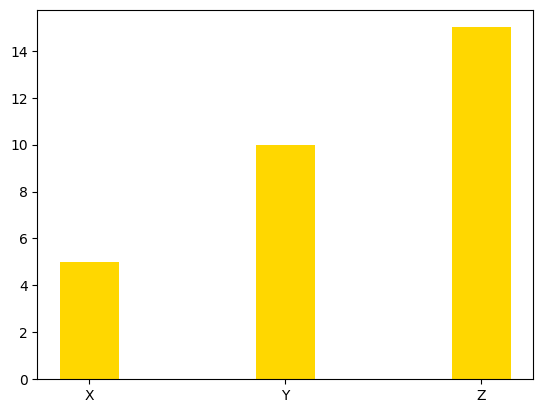

In [54]:
x = np.array(["X", "Y", "Z"])
y = np.array([5, 10, 15])
plt.bar(x,y,color = "gold",width = 0.3)
plt.show()

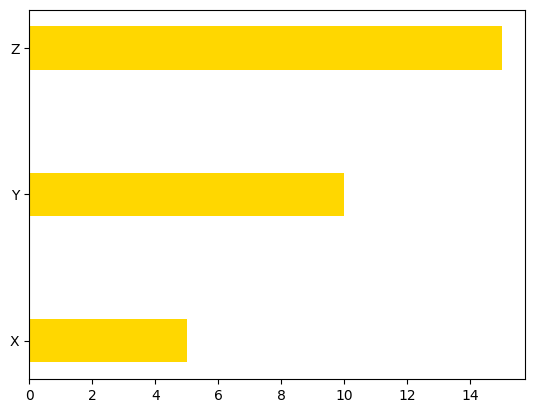

In [55]:
x = np.array(["X", "Y", "Z"])
y = np.array([5, 10, 15])
plt.barh(x,y,color = "gold",height = 0.3)
plt.show()

---

## 8. Histogram

| Part | Meaning |
|---|---|
| `np.random.normal(100, 25, 100)` | Draw **100 random samples** from a normal (bell-curve) distribution with **mean 100** and **standard deviation 25**. Arguments are `(loc, scale, size)`. |
| `print(x)` | Shows the raw numbers — worth doing once, so you see that a histogram is computed *from* a plain list of values. |
| `plt.hist(x)` | Sorts those values into **10 bins by default**, then draws one bar per bin whose height is the **count** of values in it. |

**A histogram is not a bar chart.** A bar chart takes one value per category; a histogram takes many raw values and computes the categories (bins) itself. It answers *"how is this variable distributed?"* — here, a rough bell shape centred near 100, with most values between 50 and 150 (mean ± 2 std).

⚠️ There is no `np.random.seed(...)`, so this cell produces different numbers and a slightly different chart on **every run**. Fine for teaching; set a seed for anything you want to reproduce or commit.


[ 81.2829252   91.15129514 116.10742403 104.17538577 103.1004435
  40.13223553  98.68850374  95.35637658 106.20417968  69.37054848
  92.56989867  82.14785326 110.69171743 109.59521785 103.36829867
 150.58886122 117.80192489 113.84379326 105.77609099 150.50853499
 105.22843986 118.71694336  88.88212443 106.85582667 122.11802133
  92.4784949  115.59243098 130.83143021 124.50241022 118.95398748
  89.9272784  150.13108985 163.70634022  71.59596182  50.63277664
 115.3820677   96.09666236  68.25740502 167.471692    99.25294456
  91.13829674 109.80117656 112.06291261 118.9570119  110.3368302
 117.06290435  73.36397175  69.40430168 125.2045863  108.14557398
  70.8145471  107.99028069  82.85802779  72.18417272 104.55175158
  72.97381716 110.43855742  94.1628878  170.75902854 141.295674
 130.62135207  90.21090726 137.10631239 102.21558602  64.94507887
  97.15394976  60.10385977 100.05692878 117.04194155  99.89573425
  54.39085523 103.31310885  74.65503589  96.64741768 122.71126311
  58.54728899 

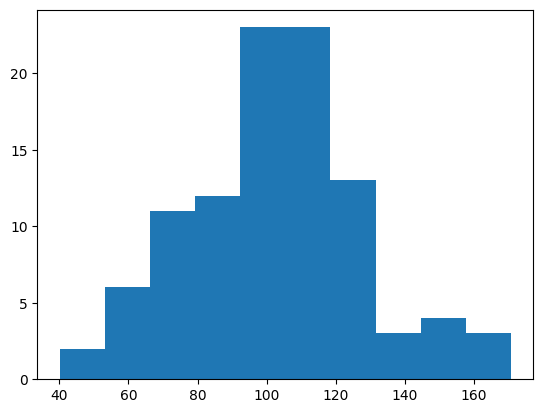

In [56]:
x = np.random.normal(100,25,100)
print(x)
plt.hist(x)
plt.show()

---

## 9. Pie charts

`x = np.array([10, 20, 30, 50])`

`plt.pie` **normalises for you**: each wedge is `value / sum`. The sum here is 110, so the wedges come out as 9.1%, 18.2%, 27.3% and 45.5%. Wedges start at the 3 o'clock position and run counter-clockwise.

| Argument | What it does |
|---|---|
| *(none)* | Anonymous colored slices — true, but useless. |
| `labels=labelss` | Attaches a name to each wedge, outside it, matched **by index**. Now the chart means something. |
| `startangle=10` | Rotates where the first wedge begins, in degrees counter-clockwise from 3 o'clock. `startangle=90` starts at the top, which is the usual choice because readers expect it. |
| `explode=[…]` | One number per wedge: how far to push it out, as a **fraction of the radius**. Length must match the data. |

### The explode lesson

`explode=[0.1, 0.12, 0.13, 0.14]` pulls **all four** wedges out by similar amounts — the gaps grow but nothing is emphasised, because emphasis is relative. `explode=[0.5, 0, 0, 0]` pulls out only MATHS (half a radius) and leaves the rest alone. That contrast is the point: **explode is for highlighting one slice, not for decorating all of them.**

### ⚠️ The bug in the last pie cell

```python
colorr = ['r','m','gold','g']
plt.pie(x, labels=labelss, startangle=90, explode=explodee)   # colorr never used!
```

`colorr` is created and **never passed**, so that cell renders exactly the same chart as the one above it, with the default palette. Python does not warn about an unused variable and matplotlib has nothing to complain about — the chart is valid, just not the one intended. The fix is one keyword:

```python
plt.pie(x, labels=labelss, startangle=90, explode=explodee, colors=colorr)
```

Note it is `colors` (plural) for `pie`, while `plot` and `scatter` use `color` / `c`. That inconsistency is exactly what causes this class of silent bug.

**Missing next step:** `autopct='%1.1f%%'` prints the percentage inside each wedge, which is what makes a pie readable at a glance.


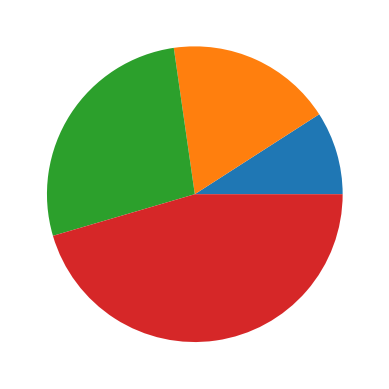

In [57]:
x = np.array([10,20,30,50])
plt.pie(x)
plt.show()

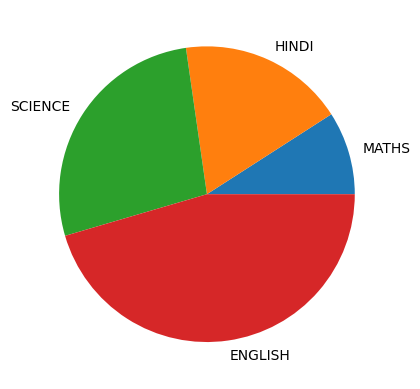

In [58]:
x = np.array([10,20,30,50])
labelss = ["MATHS", "HINDI", "SCIENCE", "ENGLISH"]
plt.pie(x,labels = labelss)
plt.show() 

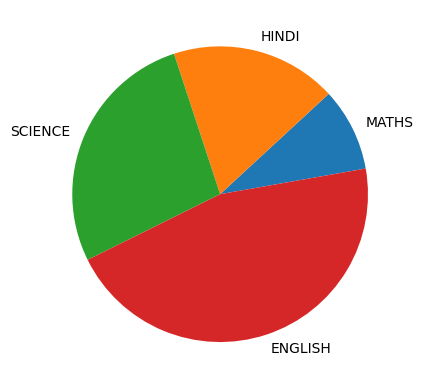

In [61]:
x = np.array([10,20,30,50])
labelss = ["MATHS", "HINDI", "SCIENCE", "ENGLISH"]
plt.pie(x,labels = labelss,startangle = 10)
plt.show() 

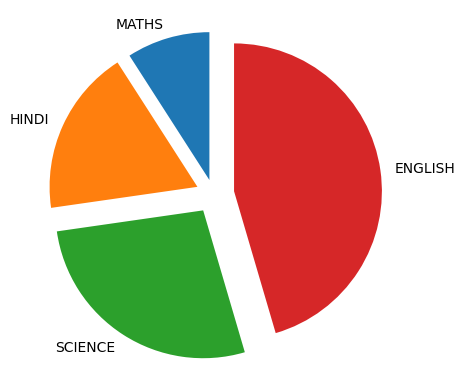

In [68]:
x = np.array([10,20,30,50])
labelss = ["MATHS", "HINDI", "SCIENCE", "ENGLISH"]
explodee = [0.1,0.12,0.13,0.14]
plt.pie(x,labels = labelss,startangle = 90,explode =explodee)
plt.show() 

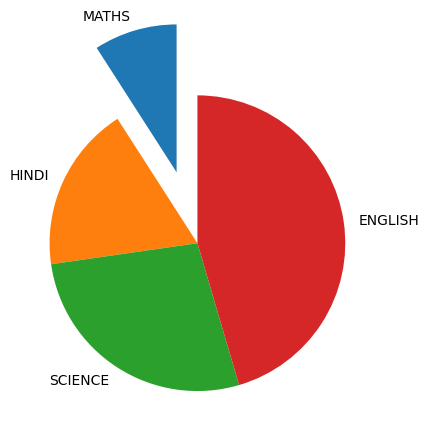

In [70]:
x = np.array([10,20,30,50])
labelss = ["MATHS", "HINDI", "SCIENCE", "ENGLISH"]
explodee = [0.5,0,0,0]
plt.pie(x,labels = labelss,startangle = 90,explode =explodee)
plt.show()

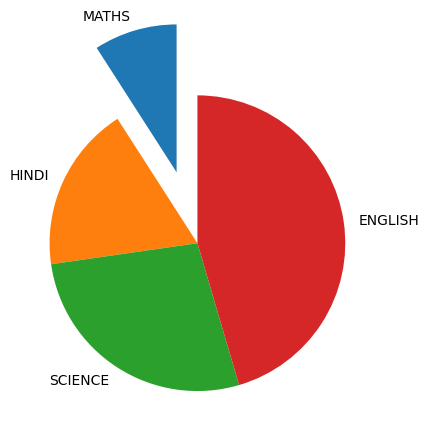

In [71]:
x = np.array([10,20,30,50])
labelss = ["MATHS", "HINDI", "SCIENCE", "ENGLISH"]
explodee = [0.5,0,0,0]
colorr = ['r','m','gold','g']
plt.pie(x,labels = labelss,startangle = 90,explode =explodee)
plt.show() 

---

## 10. Annotations

Annotations put explanatory text **on** the chart, at a data coordinate. Note the data is now **plain Python lists**, not NumPy arrays — matplotlib accepts both.

| Argument | Role |
|---|---|
| `xy=(4, 25)` | The point being annotated, in **data coordinates**. With no `xytext`, the text is placed right there — which is why the first version slightly overlaps the line. |
| `xytext=(3, 30)` | Where the **text** sits, also in data coordinates. |
| `arrowprops={"arrowstyle": "->"}` | Draws the connecting arrow. **Omit this dict and you get floating text with no arrow**, even though `xytext` is set. |

The second version solves the first version's overlap: label in clear space, arrow pointing at the subject. `arrowprops` accepts other styles such as `"-|>"` and `"fancy"`.

### Labelling every point in a loop

| Line | Explanation |
|---|---|
| `for i in range(len(x))` | Loop over positions 0, 1, 2. |
| `y[i]` | The **text** argument — the y-value itself becomes the label. It is an `int`, and matplotlib calls `str()` on it internally, so `10` renders as `"10"`. It works, but `str(y[i])` states the intent. |
| `(x[i], y[i])` | Passed **positionally**, so it lands in `xy`. Same as writing `xy=(x[i], y[i])`. |

Plot once, then loop to annotate — that is how you put value labels on a chart, and it works the same way for bars. (The indentation in that cell is a single space. Python accepts it; 4 spaces would match the rest of the file.)


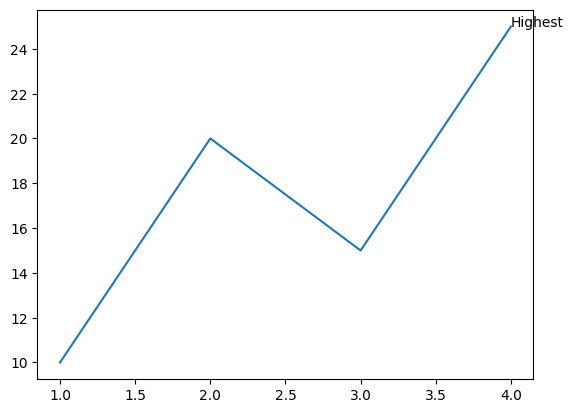

In [72]:
x = [1, 2, 3, 4]
y = [10, 20, 15, 25]
plt.plot(x, y)
plt.annotate(
 "Highest",
 xy=(4, 25)
)
plt.show()

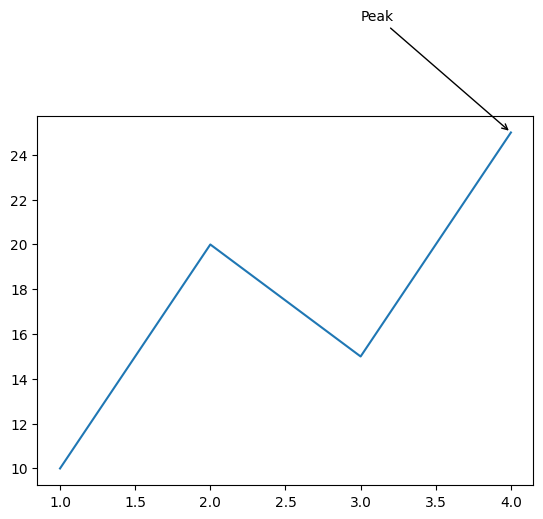

In [73]:
x = [1, 2, 3, 4]
y = [10, 20, 15, 25]
plt.plot(x, y)
plt.annotate(
 "Peak",
 xy=(4, 25),
 xytext=(3, 30),
 arrowprops={"arrowstyle": "->"}
)
plt.show()

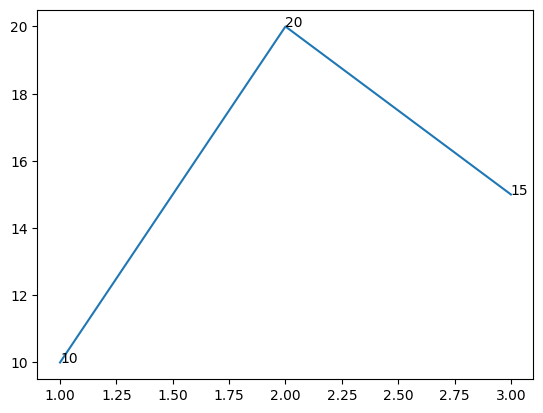

In [74]:
x = [1, 2, 3]
y = [10, 20, 15]
plt.plot(x, y)
for i in range(len(x)):
 plt.annotate(
 y[i],
 (x[i], y[i])
 )
plt.show()

---

## 11. Filled areas

`fill_between(x, y1)` shades the region between the `y` curve and **`y2 = 0`**, which is the default — so it fills from the line down to the x-axis.

The full form is `fill_between(x, y1, y2)`, which shades the band *between two curves*. That is how confidence intervals and min/max ranges are drawn, and it is the more useful version.

In the two-fill cell, each fill is still measured from zero and they are layered in call order. Because `y2` is smaller everywhere, the second (orange) fill is drawn **on top of** part of the first, hiding it.

⚠️ Two traps in one cell: no `alpha`, so the overlap is opaque rather than blended; and no `label` + `plt.legend()`, so nothing identifies the series. Compare with `plt.fill_between(x, y2, y1)` — a single call that shades only the gap between the two curves, which is usually what you actually want.


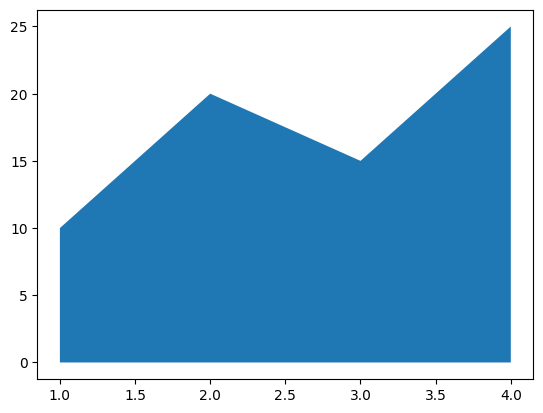

In [75]:
x = [1, 2, 3, 4]
y = [10, 20, 15, 25]
plt.fill_between(x, y)
plt.show()

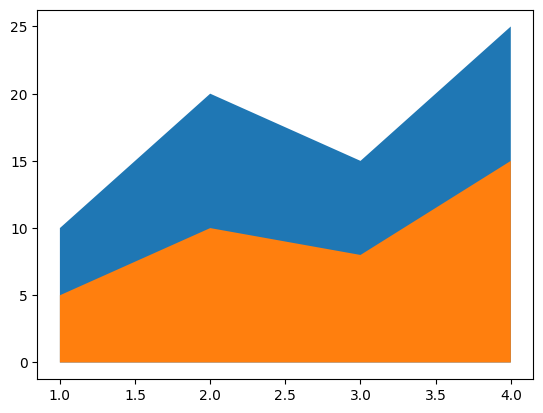

In [76]:
x = [1,2,3,4]
y1 = [10,20,15,25]
y2 = [5,10,8,15]
plt.fill_between(x, y1)
plt.fill_between(x, y2)
plt.show()

---

## 12. Saving to a file

| Line | Explanation |
|---|---|
| `plt.plot([1,2,3],[10,20,15])` | Data passed inline as lists — no variables needed. |
| `plt.savefig("chart.png")` | Writes the current figure to disk. The format comes from the **file extension** (`.png`, `.svg`, `.pdf`). The path is relative, so the file lands next to this notebook — `chart.png` in this folder is the real output of this cell. |
| `plt.show()` | Displays it afterwards. |

**The order here is correct and it matters.** `plt.show()` renders *and clears* the figure, so calling `savefig` after `show` commonly writes a **blank image**. Rule: **save first, show second.**

For real work: `dpi=300` for print resolution, and `bbox_inches="tight"` to stop long labels being cut off at the edges.


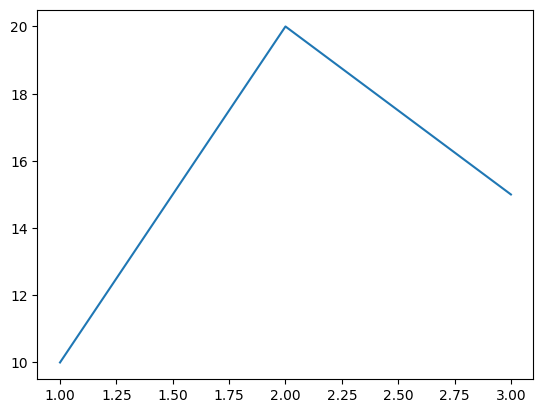

In [77]:
plt.plot([1,2,3],[10,20,15])
plt.savefig("chart.png")
plt.show()

---

# Quick reference

**Format string parts** — `plt.plot(x, y, 'o--r')`

| Markers | Line styles | Colors |
|---|---|---|
| `o` circle, `s` square, `d` thin diamond, `p` pentagon, `*` star | `-` solid, `--` dashed, `:` dotted, `-.` dash-dot | `b g r c m y k w` |

**Argument aliases used above**

| Short | Long | Applies to |
|---|---|---|
| `c` | `color` | line / marker color |
| `ms` | `markersize` | marker **diameter**, in points |
| `mec` | `markeredgecolor` | marker border |
| `mfc` | `markerfacecolor` | marker fill |

**Which chart for which question**

| Chart | Question it answers |
|---|---|
| `plot` | How does a value change across an ordered sequence? |
| `scatter` | Are two variables related? |
| `bar` / `barh` | How do categories compare? |
| `hist` | How is one variable distributed? |
| `pie` | What share does each part hold of a whole? |
| `fill_between` | What is the range, or the cumulative area? |


---

# Issues in this notebook

Ordered by how much they matter. **None of these break execution** — which is precisely why they are worth knowing.

| # | Where | Issue | Fix |
|---|---|---|---|
| 1 | last pie cell | `colorr` is defined but never passed to `plt.pie`, so the intended colors never appear — silently | add `colors=colorr` |
| 2 | per-point scatter colors | `"white"` makes one dot invisible on a white background | use a visible color, or `edgecolors='k'` |
| 3 | two-scatter cell, two-fill cell | two data series drawn with no legend | `label="..."` on each call + `plt.legend()` |
| 4 | histogram | `np.random.normal` with no seed — the chart changes every run | `np.random.seed(42)` first |
| 5 | title / label cells | `linewidth='10'` passes a string; it works only because matplotlib coerces it | `linewidth=10` |
| 6 | bubble scatter | `cmap='jet'` is not perceptually uniform and is poor for color-blind readers | `cmap='viridis'` |
| 7 | annotation loop | one-space indentation, and an `int` where a string is expected | 4-space indent, `str(y[i])` |
| 8 | first title cell | title and labels called before `plt.plot` — valid, but reads backwards | draw first, then decorate |

**One structural note:** the saved execution counts run `2, 3, 5, 7 … 77` with gaps, so these cells were run and re-run out of order rather than top-to-bottom in one clean pass. The saved images are real output, but a fresh **Restart & Run All** is what proves the notebook still reproduces today.


---

# Summary

**What this notebook is.** A hands-on tour of the `matplotlib.pyplot` API, covering six chart families and the styling arguments that apply across them. It is a reference-by-example, not a data analysis — the data is deliberately trivial so that every visual change is traceable to one argument.

**The five ideas that carry the whole file:**

1. **There is a hidden current figure.** `plt.plot`, `plt.title` and `plt.subplot` all act on whatever Axes is current. This is why order matters, and why `plt.title` attaches to one panel while `plt.suptitle` attaches to the whole figure.
2. **Style has two dialects.** The terse format string `'o--r'` and the explicit keywords `marker='o', linestyle='--', color='r'` do the same job. This notebook teaches both by running them side by side. Keywords are what you should write.
3. **Data can drive more than position.** `c=` with a numeric array plus a `cmap` encodes a third variable as color; `s=` with an array encodes a fourth as bubble area. Whenever color carries data, `plt.colorbar()` stops being optional.
4. **Pick the chart from the question, not from the look.** Line for sequence, scatter for relationship, bar for category comparison, histogram for distribution, pie for share of a whole. The `bar` vs `hist` distinction is the one people get wrong: bar takes one value per category, hist computes the categories from raw values.
5. **The finishing calls are the ones that get skipped.** Labels, legend, colorbar, and `savefig` *before* `show`. Three cells here are missing one of these, and every one of them still runs without error.

**Where this notebook stops.** No legends, no `autopct` on the pies, no object-oriented `fig, ax = plt.subplots()` style, and no chart drawn from a real Pandas DataFrame. Those are the natural next steps — especially the OO style, since that is what survives contact with real code, where you build several figures at once and cannot rely on a global "current" pointer.

**If you remember only one thing:** *matplotlib always draws into a current Figure and Axes — the chart is the data plus every styling call that lands on that Axes before you show or save it.* Get that model right and the hundreds of keyword arguments stop being something to memorise and start being something to look up.
